# **LOSS-WEIGHTED TRAINING WARNING**

**THIS NOTEBOOK USES CLASSIFICATION RESULTS TRAINED WITH CLASS-WEIGHTED LOSS INSTEAD OF WEIGHTED WINDOW SAMPLING. ITS MODEL COMPARISONS SHOULD NOT BE INTERPRETED AS RESULTS FROM THE CORRECTED SAMPLING PROCEDURE.**


# Presynaptic model comparison

Compare Mean and the full, non-ablated Graph Transformer on exact-unique CAVE presynaptic windows against TEASAR GT (`graph_transformer_teasar`) on exact-unique full new-skeleton windows. New-skeleton uniqueness includes intermediate nodes without SegCLR embeddings. Both transformer models use position, LPE, adjacency bias, global attention, and K=10 observed embeddings.

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'results' / 'presynaptic').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from analysis.presynaptic.skeleton_comparison.skeleton_comparison import (
    RESULT_ROOTS, load_summaries, load_training_curves,
    plot_confusions, plot_metric_comparison, plot_training_curves,
)
RESULT_ROOTS

{'CAVE skeleton': PosixPath('/orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/results/presynaptic/cave_skeletons'),
 'New skeleton (TEASAR)': PosixPath('/orcd/home/002/jcbliao/rotation/segclr/gnn_classifier/results/presynaptic/new_skeletons')}

## Training progress

,epoch,train_loss,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,...,window_precision_pyramidal,window_precision_thalamocortical,cell_precision_putative_cge,cell_precision_putative_parvalbumin,cell_precision_putative_somatostatin,cell_precision_pyramidal,cell_precision_thalamocortical,skeleton,run,model
99,99,0.283505,0.834251,0.740829,0.761213,0.740578,0.932127,0.794813,0.926203,0.841535,...,0.855466,0.750652,0.764706,1.000000,0.933333,0.932976,1.0,CAVE skeleton,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_fold0,Graph Transformer
199,99,0.285074,0.825500,0.724669,0.745122,0.725015,0.929864,0.786117,0.957949,0.841879,...,0.840898,0.713407,0.866667,1.000000,1.000000,0.923077,1.0,CAVE skeleton,gnn_lcpn_scratch_mean_resnet4x128_n10_fold0,Mean
299,99,0.264960,0.849905,0.725645,0.760175,0.736408,0.920814,0.777901,0.912194,0.800544,...,0.835755,0.766548,0.857143,0.971429,0.809524,0.922872,1.0,New skeleton (TEASAR),gnn_lcpn_scratch_gt_teasar_L4_H4_resnet4x128_n...,TEASAR GT


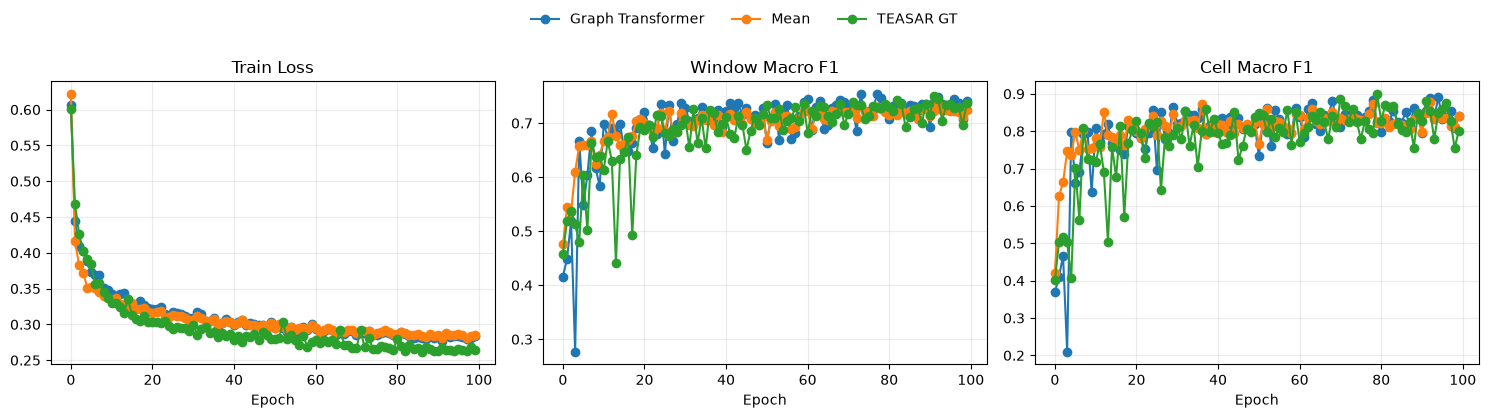

In [ ]:
curves = load_training_curves()
if curves.empty:
    print('No completed epochs yet.')
else:
    display(curves.groupby(['model', 'run']).tail(1))
    plot_training_curves(curves)

## Final metrics

,model,skeleton,run,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1
0,Graph Transformer,CAVE skeleton,gnn_lcpn_scratch_gt_L4_H4_resnet4x128_n10_fold0,0.853172,0.729773,0.784979,0.753472,0.936652,0.820109,0.941642,0.850233
1,Mean,CAVE skeleton,gnn_lcpn_scratch_mean_resnet4x128_n10_fold0,0.833156,0.739267,0.746678,0.734679,0.943439,0.830386,0.956529,0.878153
2,TEASAR GT,New skeleton (TEASAR),gnn_lcpn_scratch_gt_teasar_L4_H4_resnet4x128_n...,0.842299,0.749232,0.753845,0.750078,0.950226,0.864594,0.915485,0.880075


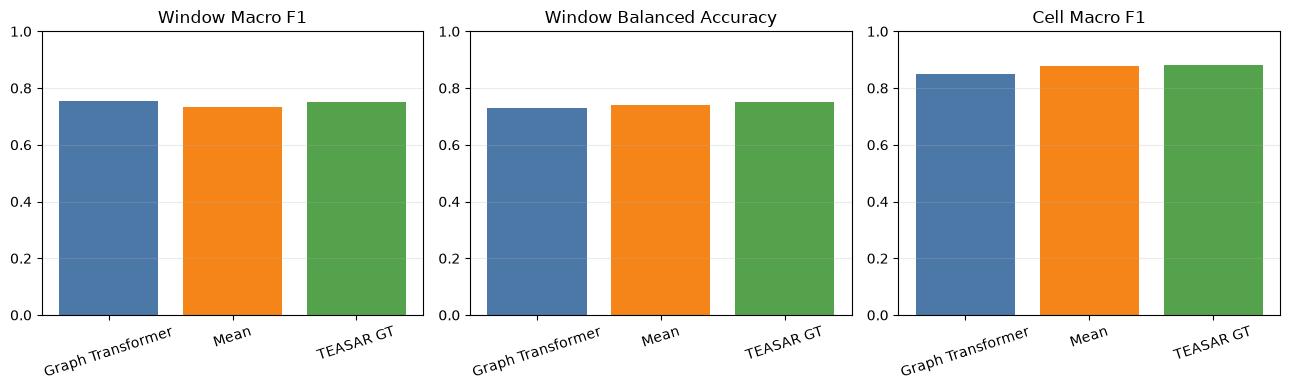

In [ ]:
summary, payloads = load_summaries()
if summary.empty:
    print('Final summaries appear after training finishes.')
else:
    display(summary)
    plot_metric_comparison(summary)

## Confusion matrices

In [ ]:
if payloads:
    plot_confusions(payloads, scope='window', normalize=True)
    plot_confusions(payloads, scope='cell', normalize=True)